# Lab 04 – Statistics Intution

## Task 1: Mean, Median, Standard Deviation, and Percentiles

### Objective

The goal of this task is to understand descriptive statistics using Python and Pandas. We will calculate the mean, median, standard deviation, and percentiles to understand the center and spread of numerical data.

### Concepts Covered

- Mean (Average)
- Median (Middle Value)
- Standard Deviation (Spread of Data)
- Percentiles (Position of Values)

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/mnt/c/Users/gursi/Downloads/WineQT.csv")
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Step 1: Explore the Dataset

Before calculating statistics, we should inspect the dataset structure and identify the available columns.

This helps us:
- verify that the dataset loaded correctly,
- identify numeric columns,
- check data types and missing values.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## Step 2: View the Available Columns

We will list all column names before selecting a feature for analysis.

In [4]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='str')

## Step 3: Calculate the Mean

The **mean** represents the average alcohol content across all wine samples.

Formula:

<math value="\\text{Mean}=\\frac{\\text{Sum of Values}}{\\text{Number of Values}}"/>

A higher mean indicates a higher average alcohol content in the dataset.

In [5]:
mean_alcohol = df["alcohol"].mean()
print("Mean Alcohol:", round(mean_alcohol, 2))

Mean Alcohol: 10.44


## Step 4: Calculate the Median

The **median** is the middle value after sorting all alcohol values.

Unlike the mean, the median is less affected by extreme values (outliers).

In [6]:
median_alcohol = df["alcohol"].median()
print("Median Alcohol:", median_alcohol)

Median Alcohol: 10.2


## Step 5: Calculate the Standard Deviation

Standard deviation measures how much alcohol values vary around the mean.

- Small value → Most wines have similar alcohol content.
- Large value → Alcohol content varies significantly.

In [7]:
std_alcohol = df["alcohol"].std()
print("Standard Deviation:", round(std_alcohol, 2))

Standard Deviation: 1.08


## Step 6: Calculate Percentiles

Percentiles help us understand the position of values within the dataset.

We will calculate:

- 25th Percentile (Q1)
- 50th Percentile (Median)
- 75th Percentile (Q3)

These quartiles will also help identify outliers later.

In [9]:
q1 = df["alcohol"].quantile(0.25)
q2 = df["alcohol"].quantile(0.50)
q3 = df["alcohol"].quantile(0.75)

print("25th Percentile (Q1):", q1)
print("50th Percentile (Median):", q2)
print("75th Percentile (Q3):", q3)

25th Percentile (Q1): 9.5
50th Percentile (Median): 10.2
75th Percentile (Q3): 11.1


## Step 7: Generate a Complete Statistical Summary

Instead of calculating every statistic separately, Pandas provides a convenient function called `describe()`.

This gives a quick overview of the numerical distribution.

In [10]:
df["alcohol"].describe()

count    1143.000000
mean       10.442111
std         1.082196
min         8.400000
25%         9.500000
50%        10.200000
75%        11.100000
max        14.900000
Name: alcohol, dtype: float64

## Task 1 Observations

- The mean represents the average alcohol content of all wines.
- The median helps identify the central value and can be compared with the mean to detect skewness.
- The standard deviation indicates how spread out the alcohol values are.
- The first and third quartiles define the middle 50% of the alcohol distribution.
- The `describe()` function provides a quick statistical overview and is one of the most commonly used functions during Exploratory Data Analysis (EDA).

# Task 2: Analyze the Distribution, Skewness, and Outliers

## Objective

The objective of this task is to visualize the distribution of alcohol values in the WineQT dataset and identify whether the data is symmetric or skewed. We will also detect potential outliers using a boxplot.

## Step 1: Import Visualization Libraries

We will use **Matplotlib** for plotting graphs.

In [11]:
import matplotlib.pyplot as plt

## Step 2: Plot a Histogram

A histogram groups continuous numerical values into intervals called **bins** and shows how many observations fall into each interval.

For this task, we will visualize the distribution of alcohol content.

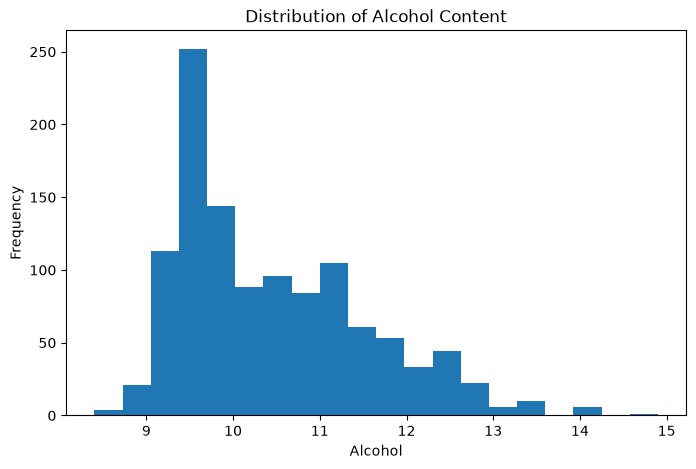

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["alcohol"], bins=20)

plt.title("Distribution of Alcohol Content")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")

plt.show()

### Observation

- The histogram shows how alcohol values are distributed across the dataset.
- If most bars are concentrated near the center, the data is more balanced.
- A longer tail on one side indicates skewness.

## Step 3: Create a Boxplot

A boxplot summarizes the distribution using quartiles and helps identify potential outliers.

/tmp/ipykernel_2062/3126271038.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["alcohol"], vert=False)


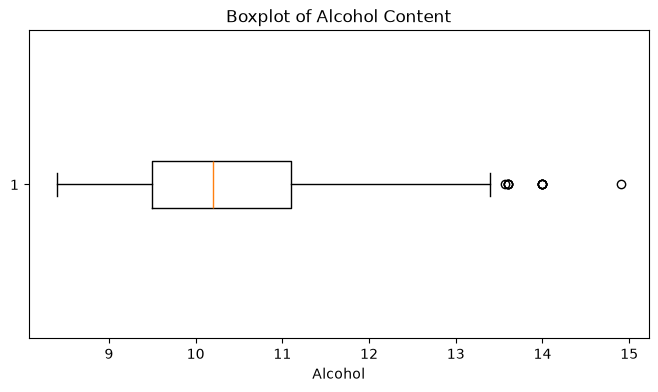

In [13]:
plt.figure(figsize=(8,4))

plt.boxplot(df["alcohol"], vert=False)

plt.title("Boxplot of Alcohol Content")
plt.xlabel("Alcohol")

plt.show()

### Observation

- The box represents the middle 50% of alcohol values (between Q1 and Q3).
- The line inside the box represents the median.
- Points outside the whiskers are potential outliers.

## Step 4: Measure Skewness Numerically

Instead of relying only on the graph, we can calculate the skewness value.

In [14]:
skewness = df["alcohol"].skew()

print("Skewness:", round(skewness, 3))

Skewness: 0.863


## Step 5: Compare Mean and Median

Comparing the mean and median helps confirm whether the distribution is skewed.

In [15]:
print("Mean:", round(df["alcohol"].mean(), 2))
print("Median:", df["alcohol"].median())

Mean: 10.44
Median: 10.2


## Task 2 Observations

- The histogram provides a visual understanding of how alcohol values are distributed.
- The boxplot highlights the median, quartiles, and potential outliers.
- The skewness value confirms whether the distribution is left-skewed, right-skewed, or nearly symmetric.
- Comparing the mean and median helps validate the direction of skewness.

# Task 3: Correlation Matrix and Relationship Analysis

## Objective

The objective of this task is to measure how numerical features in the WineQT dataset relate to each other using a correlation matrix. We will identify the strongest correlated pair and explain why correlation does not imply causation.

## Step 1: Why Correlation Matters

Correlation measures how strongly two numerical variables move together.

- **Positive correlation** means both variables tend to increase together.
- **Negative correlation** means one variable tends to decrease as the other increases.
- **Values close to 0** indicate little or no linear relationship.

## Step 2: Import Seaborn

We will use Seaborn to create a readable heatmap of the correlation matrix.

In [16]:
import seaborn as sns

## Step 3: Compute the Correlation Matrix

We calculate Pearson correlation for all numerical columns in the dataset.

In [17]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


## Step 4: Visualize the Correlation Matrix

A heatmap makes it easier to identify strong positive and negative relationships.

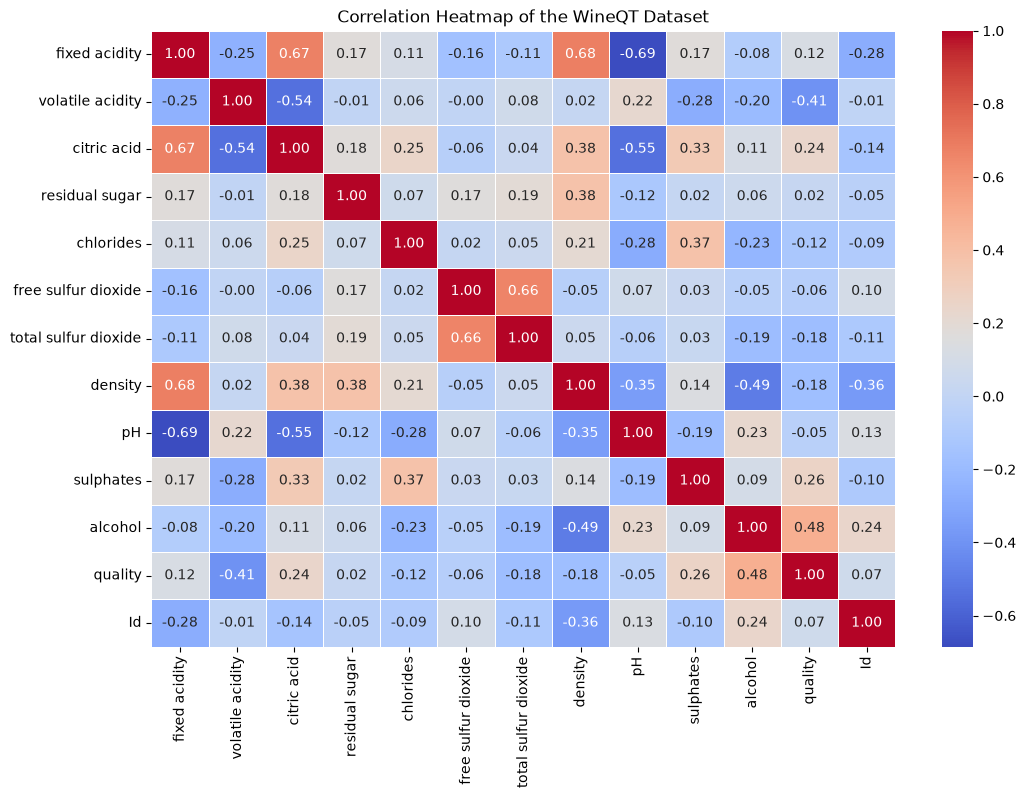

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of the WineQT Dataset")
plt.show()

## Step 5: Identify the Strongest Correlated Pair

Instead of checking every value manually, we find the strongest correlation between different variables.

In [19]:
strongest_pair = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .abs()
    .idxmax()
)

strongest_value = corr_matrix.loc[strongest_pair]

print("Strongest Pair:", strongest_pair)
print("Correlation:", round(strongest_value, 3))

Strongest Pair: ('fixed acidity', 'pH')
Correlation: -0.685


## Step 6: Correlation Does Not Mean Causation

A strong correlation does **not** prove that one variable causes the other.

For example:

- Ice cream sales and drowning incidents both increase during summer.
- Hot weather is the hidden factor that influences both.

Similarly, even if two wine features have a strong correlation, it does not automatically mean one feature causes changes in the other.

## Task 3 Observations

- The correlation matrix summarizes relationships between all numerical features.
- The heatmap makes strong positive and negative relationships easy to identify.
- The strongest correlated pair should be reported using the computed result.
- Correlation indicates association between variables, but it does not establish a cause-and-effect relationship.

# Task 4: Hypothesis Testing using an Independent T-Test

## Objective

The objective of this task is to compare the alcohol content of two groups of wines using an independent t-test. We will interpret the p-value correctly and understand what it can and cannot conclude.

## Step 1: Create Two Groups

The WineQT dataset contains a `quality` score for each wine.

For this analysis:

- **Low Quality:** Quality less than 6
- **High Quality:** Quality 6 or higher

We will compare the alcohol content of these two groups.

In [20]:
low_quality = df[df["quality"] < 6]["alcohol"]
high_quality = df[df["quality"] >= 6]["alcohol"]

print("Low Quality Samples:", len(low_quality))
print("High Quality Samples:", len(high_quality))

Low Quality Samples: 522
High Quality Samples: 621


## Step 2: Define the Hypotheses

We will test whether the average alcohol content differs between the two groups.

**Null Hypothesis (H₀):**

The mean alcohol content is the same for both groups.

<math value="H_0:\\mu_{low}=\\mu_{high}"/>

**Alternative Hypothesis (H₁):**

The mean alcohol content differs between the two groups.

<math value="H_1:\\mu_{low}\\neq\\mu_{high}"/>

## Step 3: Import the Statistical Test

We will use SciPy's `ttest_ind()` function to compare the two independent groups.

In [21]:
from scipy.stats import ttest_ind

## Step 4: Perform the Independent T-Test

The t-test compares the average alcohol content of the two groups while considering variation within each group.

In [22]:
t_stat, p_value = ttest_ind(high_quality, low_quality)

print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 5))

T-statistic: 16.569
P-value: 0.0


## Step 5: Compare the Group Means

Before interpreting the statistical test, we should also compare the average alcohol content of both groups.

In [23]:
print("Mean Alcohol (High Quality):", round(high_quality.mean(), 2))
print("Mean Alcohol (Low Quality):", round(low_quality.mean(), 2))

Mean Alcohol (High Quality): 10.88
Mean Alcohol (Low Quality): 9.92


## Step 5: Compare the Group Means

Before interpreting the statistical test, we should also compare the average alcohol content of both groups.

In [24]:
print("Mean Alcohol (High Quality):", round(high_quality.mean(), 2))
print("Mean Alcohol (Low Quality):", round(low_quality.mean(), 2))

Mean Alcohol (High Quality): 10.88
Mean Alcohol (Low Quality): 9.92


## Step 6: Interpret the Results

Decision Rule:

- If **p-value < 0.05**, reject the null hypothesis.
- If **p-value ≥ 0.05**, fail to reject the null hypothesis.

In [25]:
if p_value < 0.05:
    print("Reject the Null Hypothesis.")
    print("There is evidence of a significant difference in alcohol content between the two quality groups.")
else:
    print("Fail to Reject the Null Hypothesis.")
    print("There is not enough evidence of a significant difference.")

Reject the Null Hypothesis.
There is evidence of a significant difference in alcohol content between the two quality groups.


## What the P-Value Does and Does Not Tell Us

### What it tells us

- Whether the observed difference is statistically significant under the null hypothesis.
- Whether the result is unlikely to occur due to random chance alone.

### What it does **not** tell us

- It does not prove that alcohol causes higher wine quality.
- It does not measure how large or practically important the difference is.
- It does not give the probability that the null hypothesis is true.

## Task 4 Observations

- The wines were divided into two quality groups based on their quality score.
- An independent t-test was used to compare their average alcohol content.
- The decision was made using a significance level of 0.05.
- The p-value was interpreted as evidence for or against a statistically significant difference.
- A statistically significant result indicates an association in the sample, but it does not establish a cause-and-effect relationship.